# Using Metrics for Classification

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Import the Iris Dataset

In [4]:
from sklearn.datasets import load_iris

iris = load_iris()
x = iris.data
y = iris.target 

data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data['target'] = iris.target
data['target_names'] = data['target'].map({i:name for i, name in enumerate(iris.target_names)})

print(data.head().to_markdown(index=False, numalign="left", stralign="left"))

| sepal length (cm)   | sepal width (cm)   | petal length (cm)   | petal width (cm)   | target   | target_names   |
|:--------------------|:-------------------|:--------------------|:-------------------|:---------|:---------------|
| 5.1                 | 3.5                | 1.4                 | 0.2                | 0        | setosa         |
| 4.9                 | 3                  | 1.4                 | 0.2                | 0        | setosa         |
| 4.7                 | 3.2                | 1.3                 | 0.2                | 0        | setosa         |
| 4.6                 | 3.1                | 1.5                 | 0.2                | 0        | setosa         |
| 5                   | 3.6                | 1.4                 | 0.2                | 0        | setosa         |


# Split the Data into Training & Testing Sets

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
# test size means 30% is set for data testing
# the random state ensures the split is consistent everytime the test is run 

# Run a Logistic Regression Analysis

In [7]:
log_reg = LogisticRegression()
log_reg.fit(x_train, y_train)

decision_tree = DecisionTreeClassifier()
decision_tree.fit(x_train, y_train)

DecisionTreeClassifier()

#### Check the Accuracy of the Data

In [ ]:
y_pred_log_reg = log_reg.predict(x_test)
y_pred_dt = decision_tree.predict(x_test)

accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

# calculates the accuracy - determines which model is better for future prediction

print("Logistic Regression Accuracy:", accuracy_log_reg)
print("Decision Tree Accuracy:", accuracy_dt)

Logistic Regression Accuracy: 1.0
Decision Tree Accuracy: 1.0


In [ ]:
precision_log_reg = precision_score(y_test, y_pred_log_reg, average="weighted")
recall_log_reg = recall_score(y_test, y_pred_log_reg, average="weighted")

precision_dt = precision_score(y_test, y_pred_dt, average="weighted")
recall_dt = recall_score(y_test, y_pred_dt, average="weighted")

# manages how many positives the model was able to identify

print("Logistic Regression Precision:", precision_log_reg)
print("Logistic Regression Recall:", recall_log_reg)
print("Decision Tree Precision:", precision_dt)
print("Decision Tree Recall:", recall_dt)

Logistic Regression Precision: 1.0
Logistic Regression Recall: 1.0
Decision Tree Precision: 1.0
Decision Tree Recall: 1.0


In [11]:
f1_log_reg = f1_score(y_test, y_pred_log_reg, average="weighted")
f1_dt = f1_score(y_test, y_pred_dt, average="weighted")

print("Logistic Regression F1 Score:", f1_log_reg)
print("Decision Tree F1 Score:", f1_dt)

Logistic Regression F1 Score: 1.0
Decision Tree F1 Score: 1.0


#### Create a Confusion Matrix of the Data

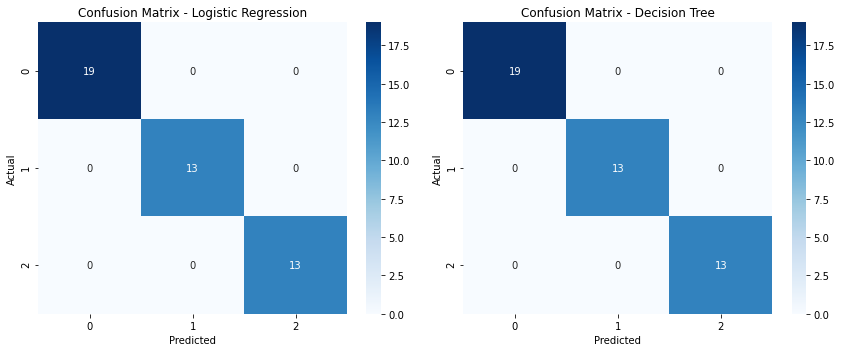

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Plot confusion matrices 

# Logistic Regression Confusion Matrix
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
sns.heatmap(cm_log_reg, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix - Logistic Regression')

# Decision Tree Confusion Matrix
cm_decision_tree = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_decision_tree, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix - Decision Tree')

plt.tight_layout()
plt.show()